# Ex12 GRU vs LSTM predicting sin(a**2)

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
series = np.sin((0.1*np.arange(400))**2)

400


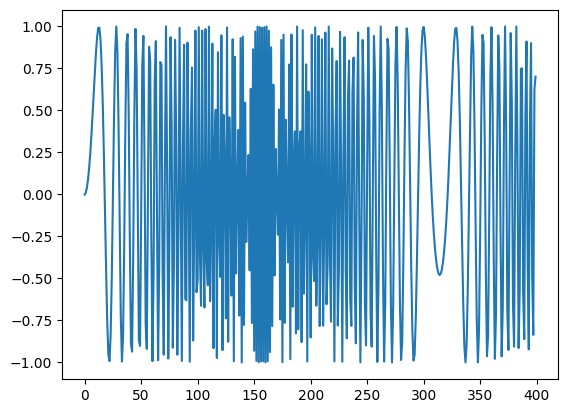

In [3]:
plt.plot(series)
print(len(series))
plt.show()

In [4]:
T = 10
D = 1 
M = 10
L = 1
N = len(series)
K = 1

## make the data

In [5]:
X,y = [],[]

for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

X = np.array(X).reshape(-1,T,D)
y = np.array(y).reshape(-1,1)

In [6]:
X_train,X_test = X[:N//2],X[N//2:]
y_train,y_test = y[:N//2],y[N//2:]

In [7]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

## Model Classes

In [8]:
class GRU(nn.Module):
    def __init__(self, input_size,hidden_size,num_layers,output_size,bidirectional=False):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = output_size
        self.bidirectional = bidirectional

        self.rnn = nn.GRU(input_size=self.D,
                          hidden_size=self.M,
                          num_layers=self.L,
                          batch_first=True,
                          bidirectional=bidirectional)
        self.fc = nn.Linear(self.M*2 if self.bidirectional else self.M,
                            out_features=self.K)
        
    def forward(self,X):
        h0 = torch.zeros(self.L*2 if self.bidirectional else self.L,X.size(0),self.M)
        output,h_t = self.rnn(X,h0)
        #output shape NxTxM , 
        output = self.fc(output[:,-1,:]) # we  want the last time so it will be NxM
        #output now is NxK
        return output

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size,hidden_size,num_layers,output_size,bidirectional=False):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = output_size

        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           batch_first=True,
                           bidirectional=bidirectional)
        
        self.fc = nn.Linear(self.M,self.K)

    def forward(self,X):
        h0 = torch.zeros(self.L,X.size(0),self.M)
        c0 = torch.zeros(self.L,X.size(0),self.M)

        out,(h_t,c_t) = self.rnn(X,(h0,c0))
        #out is NxTxM , fc recieves NxM->NxK we take latest T
        out = self.fc(out[:,-1,:]) 
        return out

In [10]:
device = print('cuda:0' if torch.cuda.is_available() else 'cpu')

cuda:0


In [11]:
def train_loop(model,optimizer:opt.Optimizer,creterion:nn.Module,epochs):
    train_loss = []
    val_loss = []
    lr_reduce_on_platau = opt.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',patience=20)
    for epoch in range(epochs):
        optimizer.zero_grad()

        y_hat = model(X_train)
        loss = creterion(y_hat,y_train)
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        lr_reduce_on_platau.step(loss)

        #test
        y_hat = model(X_test)
        loss = creterion(y_hat,y_test)
        val_loss.append(loss.item())

        print(f'train loss {train_loss[-1]} test loss {val_loss[-1]}')

    return train_loss,val_loss

In [12]:
gru = GRU(D,M,L,K,False).to(device=device)
gru_criterion = nn.MSELoss()
gru_optimizer = opt.Adam(gru.parameters(),lr=0.05)

In [13]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device=device)
y_test = y_test.to(device)

In [14]:
lstm = LSTMModel(D,M,L,K,False).to(device=device)
lstm_criterion = nn.MSELoss()
lstm_optimizer = opt.Adam(lstm.parameters(),lr=0.05)

In [15]:
epochs = 1000

In [16]:
gru_train_loss,gru_test_loss = train_loop(gru,gru_optimizer,gru_criterion,epochs)

train loss 0.5349572896957397 test loss 0.5377033948898315
train loss 0.5594063401222229 test loss 0.5256855487823486
train loss 0.506874680519104 test loss 0.5607318878173828
train loss 0.5019373893737793 test loss 0.6073473691940308
train loss 0.5068938136100769 test loss 0.6406112909317017
train loss 0.5032174587249756 test loss 0.6592162251472473
train loss 0.49725890159606934 test loss 0.6630057096481323
train loss 0.49430179595947266 test loss 0.653647243976593
train loss 0.4942467510700226 test loss 0.6358585357666016
train loss 0.49492043256759644 test loss 0.6147416830062866
train loss 0.49405229091644287 test loss 0.595451831817627
train loss 0.49099722504615784 test loss 0.5826466083526611
train loss 0.4867282211780548 test loss 0.5788679122924805
train loss 0.4822630286216736 test loss 0.5836122035980225
train loss 0.4775659441947937 test loss 0.5930671095848083
train loss 0.47134095430374146 test loss 0.5997729897499084
train loss 0.4617270231246948 test loss 0.59320688247

In [17]:
lstm_train_losses,lstm_test_losses =train_loop(model=lstm,optimizer=lstm_optimizer,creterion=lstm_criterion,epochs=epochs)

train loss 0.5843490958213806 test loss 0.4944727420806885
train loss 0.5194993615150452 test loss 0.52049720287323
train loss 0.5199953317642212 test loss 0.5299913287162781
train loss 0.5035965442657471 test loss 0.5498303174972534
train loss 0.49898695945739746 test loss 0.5736714005470276
train loss 0.49635446071624756 test loss 0.6008010506629944
train loss 0.4932251274585724 test loss 0.6315831542015076
train loss 0.4910210371017456 test loss 0.662123441696167
train loss 0.491049587726593 test loss 0.6816584467887878
train loss 0.4916495084762573 test loss 0.6827418804168701
train loss 0.48988044261932373 test loss 0.6685817241668701
train loss 0.48563575744628906 test loss 0.6469864845275879
train loss 0.4808153510093689 test loss 0.6251643896102905
train loss 0.4766811728477478 test loss 0.6077700853347778
train loss 0.47268059849739075 test loss 0.5966419577598572
train loss 0.46703362464904785 test loss 0.5915724039077759
train loss 0.45831984281539917 test loss 0.59075021743

In [18]:
ticks = [x for x in range(epochs)]

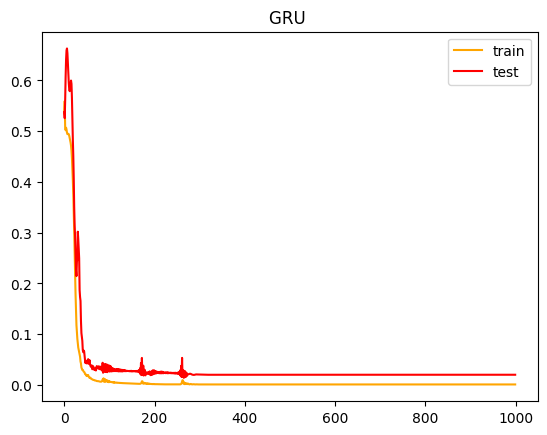

In [19]:
plt.title(f"GRU {'bidirectional' if gru.bidirectional else '' }")
plt.plot(gru_train_loss,color='orange',label='train')
plt.plot(gru_test_loss,color='red',label='test')
plt.legend()
plt.show()

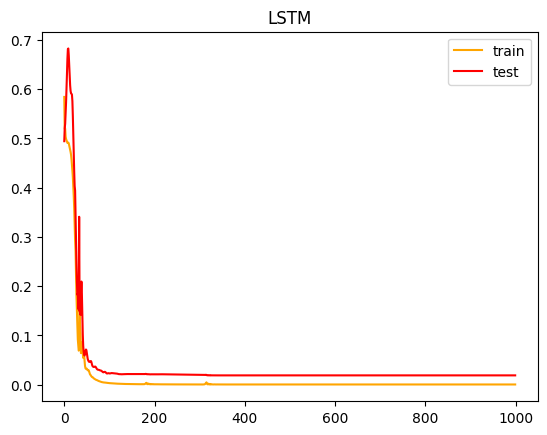

In [20]:
plt.title("LSTM")
plt.plot(lstm_train_losses,color='orange',label='train')
plt.plot(lstm_test_losses,color='red',label='test')
plt.legend()
plt.show()

In [21]:

times = len(y_test)

In [22]:
def predict_validation(model,X):
    X_last = X[0]
    predictions = []
    for i in range(times):
        X_last = X_last.view(1,T,D)
        pred = model(X_last)
        predictions.append(pred.item())
        X_last = torch.concat((X_last[-1,1:],pred))

    return predictions

In [25]:
gru_preds = predict_validation(model=gru,X=X_test)
lstm_preds = predict_validation(model=lstm,X=X_test)


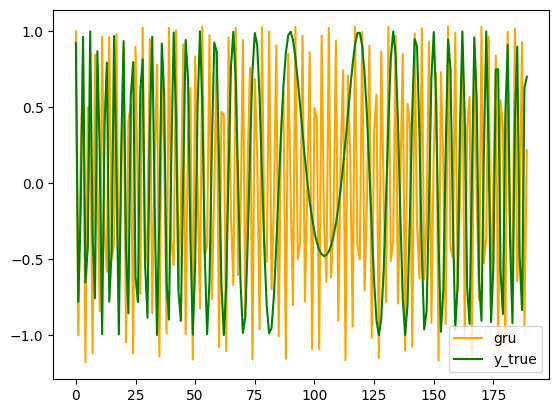

In [27]:
plt.plot(gru_preds,label='gru',color='orange')
plt.plot(y_test,label='y_true',color='green')

plt.legend()
plt.show()

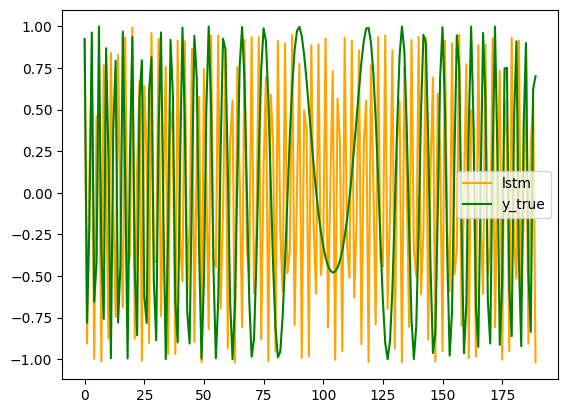

In [29]:
plt.plot(lstm_preds,label='lstm',color='orange')
plt.plot(y_test,label='y_true',color='green')

plt.legend()
plt.show()